<a href="https://colab.research.google.com/github/Umer-Ashfaq/AI-600/blob/main/24280004_AI600_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Describing the Dataset Structure: Number of samples, Number of features and Data Types**

In [28]:
import pandas as pd

# Load training data
train = pd.read_csv("train.csv")

# Number of samples
n_samples = train.shape[0]
n_cols = train.shape[1]

# Target + features count
target_col = "price_class"
n_features = n_cols - 1  # assuming only 1 target column

print("=== Dataset Structure (train.csv) ===")
print(f"Number of samples (rows): {n_samples}")
print(f"Total columns: {n_cols}")
print(f"Number of features: {n_features}")
print(f"Target column: {target_col}")

# Data types of each column
print("\n=== Column Data Types ===")
print(train.dtypes)


=== Dataset Structure (train.csv) ===
Number of samples (rows): 41348
Total columns: 7
Number of features: 6
Target column: price_class

=== Column Data Types ===
neighbourhood_group     object
room_type               object
minimum_nights         float64
amenity_score          float64
number_of_reviews      float64
availability_365       float64
price_class              int64
dtype: object


**Identifying the Missing Values for Each Feature and the Strategy Used to Handle missing Data and Justifying my Choice:**

In [29]:
# Identifying Missing Values
missing_count = train.isna().sum()
missing_percent = (missing_count / len(train) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

print("=== Missing Values Summary (per column) ===")
print(missing_summary)

# My Strategy to Handle Missing Data
target_col = "price_class"
cat_cols = ["neighbourhood_group", "room_type"]
num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]

df = train.copy()

# Filling Categorical with Mode
for c in cat_cols:
    if df[c].isna().any():
        mode_val = df[c].mode(dropna=True)[0]
        df[c] = df[c].fillna(mode_val)
        print(f"[Impute] {c}: filled missing with MODE = {mode_val}")

# Filling Numerical with Median
for c in num_cols:
    if df[c].isna().any():
        med_val = df[c].median()
        df[c] = df[c].fillna(med_val)
        print(f"[Impute] {c}: filled missing with MEDIAN = {med_val}")

# Verifying no Missing Values Left
print("\n=== Missing Values After Imputation ===")
print(df[cat_cols + num_cols + [target_col]].isna().sum())

=== Missing Values Summary (per column) ===
                     missing_count  missing_percent
minimum_nights                1322             3.20
number_of_reviews             1123             2.72
amenity_score                  916             2.22
neighbourhood_group            839             2.03
room_type                      611             1.48
availability_365               595             1.44
price_class                      0             0.00
[Impute] neighbourhood_group: filled missing with MODE = Manhattan
[Impute] room_type: filled missing with MODE = Entire home/apt
[Impute] minimum_nights: filled missing with MEDIAN = 3.0
[Impute] number_of_reviews: filled missing with MEDIAN = 5.0
[Impute] availability_365: filled missing with MEDIAN = 44.0
[Impute] amenity_score: filled missing with MEDIAN = 51.4

=== Missing Values After Imputation ===
neighbourhood_group    0
room_type              0
minimum_nights         0
number_of_reviews      0
availability_365       0
amenit

**Justification:** Missingness is low (max ≈ 3.2%), so dropping rows would waste data.
- Mode imputation is suitable for categorical features (keeps most likely category).
- Median imputation is suitable for numerical features because it is robust to outliers/skew.
- This preserves dataset size and reduces bias/variance compared to dropping rows.

**Analyze and Report the Class Distribution of the Target Variable. Include a Visualization and Comment on Imbalance:**

=== Class Distribution (price_class) ===
             count  percent
price_class                
0             5567    13.46
1            23287    56.32
2             9844    23.81
3             2650     6.41


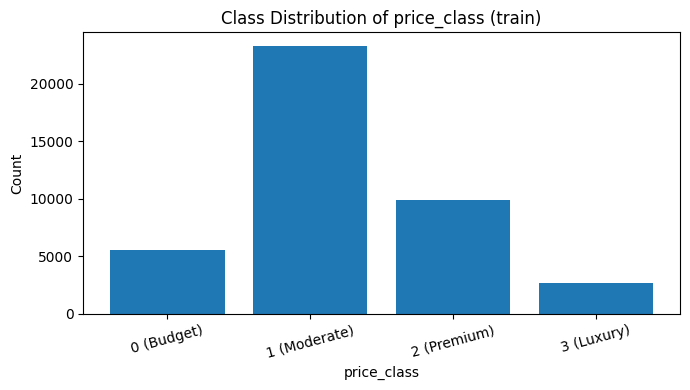


=== Imbalance Comment ===
Majority class: 1 (Moderate) -> 56.32%
Minority class: 3 (Luxury) -> 6.41%
Imbalance ratio (major/minor): 8.79x
Comment: The dataset is noticeably imbalanced. Consider class weights or balanced sampling in training.


In [30]:
import matplotlib.pyplot as plt

# Load training data
train = pd.read_csv("train.csv")
target_col = "price_class"

class_counts = train[target_col].value_counts().sort_index()
class_perc = (class_counts / len(train) * 100).round(2)

dist_table = pd.DataFrame({
    "count": class_counts,
    "percent": class_perc
})

print("=== Class Distribution (price_class) ===")
print(dist_table)

# Visualization: bar chart

label_map = {0: "Budget", 1: "Moderate", 2: "Premium", 3: "Luxury"}
x_labels = [f"{i} ({label_map.get(i, str(i))})" for i in dist_table.index]

plt.figure(figsize=(7,4))
plt.bar(x_labels, dist_table["count"].values)
plt.xlabel("price_class")
plt.ylabel("Count")
plt.title("Class Distribution of price_class (train)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Comment on imbalance

major_class = dist_table["count"].idxmax()
minor_class = dist_table["count"].idxmin()
imbalance_ratio = dist_table.loc[major_class, "count"] / dist_table.loc[minor_class, "count"]

print("\n=== Imbalance Comment ===")
print(f"Majority class: {major_class} ({label_map.get(major_class)}) -> {dist_table.loc[major_class,'percent']}%")
print(f"Minority class: {minor_class} ({label_map.get(minor_class)}) -> {dist_table.loc[minor_class,'percent']}%")
print(f"Imbalance ratio (major/minor): {imbalance_ratio:.2f}x")

if imbalance_ratio >= 3:
    print("Comment: The dataset is noticeably imbalanced. Consider class weights or balanced sampling in training.")
elif imbalance_ratio >= 1.5:
    print("Comment: Mild-to-moderate imbalance exists. Monitor metrics per class (e.g., F1/recall) in addition to accuracy.")
else:
    print("Comment: Class distribution is fairly balanced.")

**Encode Categorical Variables Using an Appropriate Encoding Scheme. Justify your choice**

In [31]:
# One-hot encode categorical variables
X = df[cat_cols + num_cols]
y = df[target_col].astype(int)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False)

print("=== Before encoding ===")
print("X shape:", X.shape)
print("Categorical columns:", cat_cols)

print("\n=== After one-hot encoding ===")
print("X_encoded shape:", X_encoded.shape)
print("New columns created:", [c for c in X_encoded.columns if c.startswith("neighbourhood_group_") or c.startswith("room_type_")])


=== Before encoding ===
X shape: (41348, 6)
Categorical columns: ['neighbourhood_group', 'room_type']

=== After one-hot encoding ===
X_encoded shape: (41348, 12)
New columns created: ['neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']


**Justification:** I used one-hot encoding because neighbourhood_group and room_type are nominal categories:

    - One-hot avoids creating artificial ranking that label-encoding would introduce.
    - Category counts are small (few unique values), so one-hot is efficient and works well with MLPs.

**Normalize Your Numerical Features and Clearly State the Method Used for Normalization, and why?**

In [32]:
import numpy as np

skew_before = df[num_cols].skew(numeric_only=True)

df["minimum_nights"] = np.log1p(df["minimum_nights"])
df["number_of_reviews"] = np.log1p(df["number_of_reviews"])

skew_after = df[num_cols].skew(numeric_only=True)

print("=== Skewness before log1p ===")
print(skew_before.round(3))
print("\n=== Skewness after log1p (min_nights & num_reviews) ===")
print(skew_after.round(3))


# Z-score standardization

mu = df[num_cols].mean()
sigma = df[num_cols].std(ddof=0).replace(0, 1)

df[num_cols] = (df[num_cols] - mu) / sigma

print("\n=== Check: standardized means (approx 0) ===")
print(df[num_cols].mean().round(3))

print("\n=== Check: standardized stds (approx 1) ===")
print(df[num_cols].std(ddof=0).round(3))

=== Skewness before log1p ===
minimum_nights       21.226
number_of_reviews     3.668
availability_365      0.797
amenity_score         0.086
dtype: float64

=== Skewness after log1p (min_nights & num_reviews) ===
minimum_nights       1.517
number_of_reviews    0.353
availability_365     0.797
amenity_score        0.086
dtype: float64

=== Check: standardized means (approx 0) ===
minimum_nights      -0.0
number_of_reviews   -0.0
availability_365    -0.0
amenity_score        0.0
dtype: float64

=== Check: standardized stds (approx 1) ===
minimum_nights       1.0
number_of_reviews    1.0
availability_365     1.0
amenity_score        1.0
dtype: float64


**Justification:**  

I applied log1p to minimum_nights and number_of_reviews to reduce strong skew and outlier impact and then I applied Z-score standardization to all numerical features: x' = (x - mean) / std.

    - This keeps features on a comparable scale (mean≈0, std≈1), which stabilizes and speeds up MLP training.
    - I computed Mean/std on the training set only to avoid data leakage.

**Plotting and Analyzing Relationships Between Individual Features and the Target Variable Using Suitable Visualizations:**

/tmp/ipython-input-2784822304.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(k) for k in classes], showfliers=False)


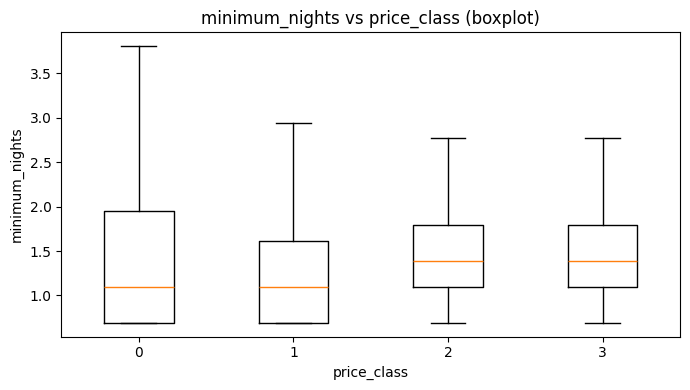

/tmp/ipython-input-2784822304.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(k) for k in classes], showfliers=False)


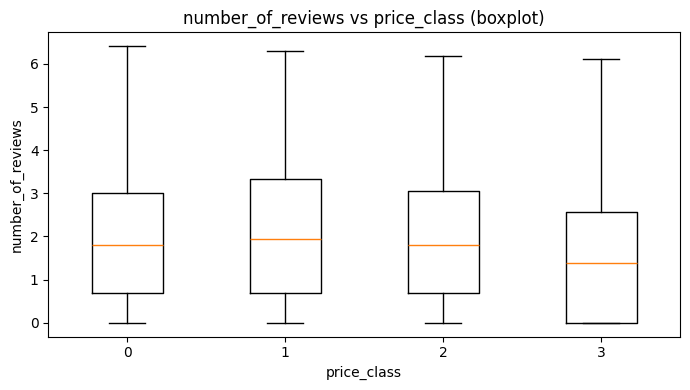

/tmp/ipython-input-2784822304.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(k) for k in classes], showfliers=False)


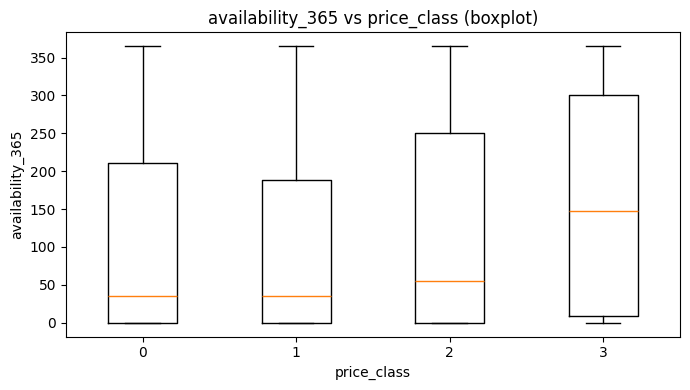

/tmp/ipython-input-2784822304.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(k) for k in classes], showfliers=False)


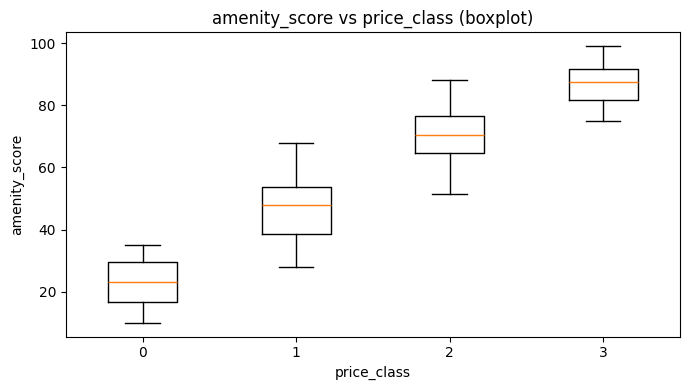

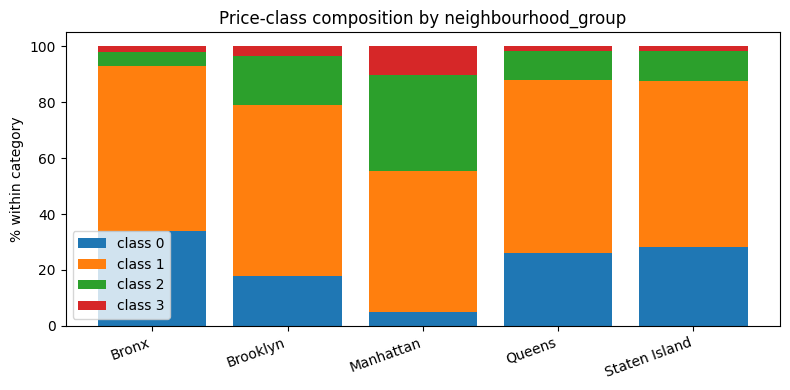

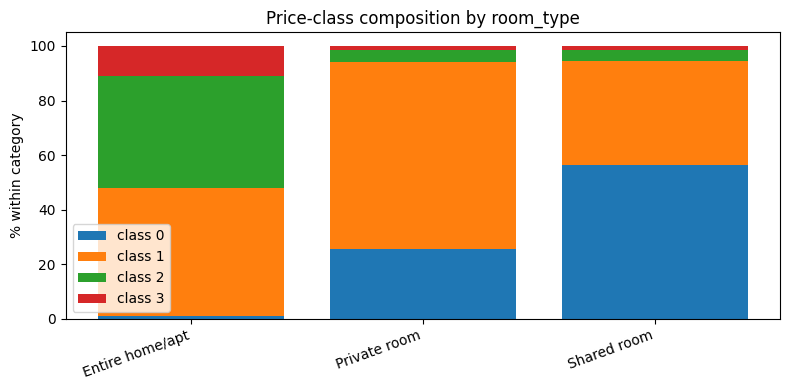


=== Mean of numerical features by price_class ===
             minimum_nights  number_of_reviews  availability_365  \
price_class                                                        
0                     1.533              1.889           106.325   
1                     1.437              2.138           102.043   
2                     1.601              1.930           121.348   
3                     1.588              1.559           160.075   

             amenity_score  
price_class                 
0                   23.583  
1                   47.039  
2                   70.433  
3                   86.413  

=== Median of numerical features by price_class ===
             minimum_nights  number_of_reviews  availability_365  \
price_class                                                        
0                     1.099              1.792              35.0   
1                     1.099              1.946              35.0   
2                     1.386              

In [33]:
# Load training data
train = pd.read_csv("train.csv")  # or full path

target_col = "price_class"
cat_cols = ["neighbourhood_group", "room_type"]
num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]

df = train.copy()

# Handle missing values (so plots don’t break)

for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

# Optional: reduce skew in heavy-tailed numeric features for cleaner plots
df["minimum_nights"] = np.log1p(df["minimum_nights"])
df["number_of_reviews"] = np.log1p(df["number_of_reviews"])


# Numeric features vs target: boxplots

classes = sorted(df[target_col].unique())

for col in num_cols:
    plt.figure(figsize=(7,4))
    data = [df.loc[df[target_col] == k, col].values for k in classes]
    plt.boxplot(data, labels=[str(k) for k in classes], showfliers=False)
    plt.xlabel("price_class")
    plt.ylabel(col)
    plt.title(f"{col} vs price_class (boxplot)")
    plt.tight_layout()
    plt.show()


# Categorical features vs target: stacked % bar chart
def stacked_percent_bar(cat_col):
    tab = pd.crosstab(df[cat_col], df[target_col], normalize="index") * 100
    x = np.arange(tab.shape[0])
    bottom = np.zeros(tab.shape[0])

    plt.figure(figsize=(8,4))
    for cls in tab.columns:
        vals = tab[cls].values
        plt.bar(x, vals, bottom=bottom, label=f"class {cls}")
        bottom += vals

    plt.xticks(x, tab.index, rotation=20, ha="right")
    plt.ylabel("% within category")
    plt.title(f"Price-class composition by {cat_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    stacked_percent_bar(col)


# Quick quantitative support: group means by class (numerics)

print("\n=== Mean of numerical features by price_class ===")
print(df.groupby(target_col)[num_cols].mean().round(3))

print("\n=== Median of numerical features by price_class ===")
print(df.groupby(target_col)[num_cols].median().round(3))


# Optional: Categorical -> distribution table (percent) for reporting

for col in cat_cols:
    print(f"\n=== % distribution of price_class within each {col} ===")
    print((pd.crosstab(df[col], df[target_col], normalize="index") * 100).round(2))


**Visualizing the Correlation Matrix Among Numerical Features. Identify and Discuss Highly Correlated Feature Pairs:**

=== Correlation matrix (Pearson) ===
                   minimum_nights  number_of_reviews  availability_365  \
minimum_nights              1.000             -0.219             0.162   
number_of_reviews          -0.219              1.000             0.172   
availability_365            0.162              0.172             1.000   
amenity_score               0.065             -0.046             0.079   

                   amenity_score  
minimum_nights             0.065  
number_of_reviews         -0.046  
availability_365           0.079  
amenity_score              1.000  


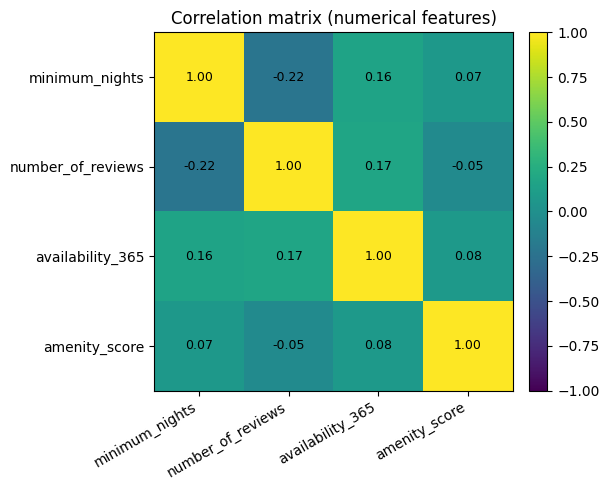


=== Highly correlated pairs (|corr| >= 0.8) ===
No highly correlated numerical feature pairs found at this threshold.

=== Top absolute correlations (for discussion) ===
minimum_nights vs number_of_reviews: corr = -0.219
number_of_reviews vs availability_365: corr = 0.172
minimum_nights vs availability_365: corr = 0.162
availability_365 vs amenity_score: corr = 0.079
minimum_nights vs amenity_score: corr = 0.065


In [34]:
num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]

df = train.copy()

# Handle missing values (numerical) so correlation works

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

df["minimum_nights"] = np.log1p(df["minimum_nights"])
df["number_of_reviews"] = np.log1p(df["number_of_reviews"])


# Correlation matrix (Pearson)

corr_df = df[num_cols].corr(method="pearson")
print("=== Correlation matrix (Pearson) ===")
print(corr_df.round(3))


# Visualize correlation matrix (matplotlib heatmap)
plt.figure(figsize=(6,5))
im = plt.imshow(corr_df.values, vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=30, ha="right")
plt.yticks(range(len(num_cols)), num_cols)

# annotate values
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr_df.values[i, j]:.2f}",
                 ha="center", va="center", fontsize=9)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Correlation matrix (numerical features)")
plt.tight_layout()
plt.show()


# Identify highly correlated pairs (|corr| >= threshold)
threshold = 0.80

pairs = []
cols = corr_df.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr_df.iloc[i, j]
        if abs(val) >= threshold:
            pairs.append((cols[i], cols[j], val))

print(f"\n=== Highly correlated pairs (|corr| >= {threshold}) ===")
if len(pairs) == 0:
    print("No highly correlated numerical feature pairs found at this threshold.")
else:
    for a, b, v in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{a} vs {b}: corr = {v:.3f}")

all_pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        all_pairs.append((cols[i], cols[j], corr_df.iloc[i, j]))

top = sorted(all_pairs, key=lambda x: abs(x[2]), reverse=True)[:5]
print("\n=== Top absolute correlations (for discussion) ===")
for a, b, v in top:
    print(f"{a} vs {b}: corr = {v:.3f}")


Features expected to be most influential are as follows:

**amenity_score:** It shows the clearest separation across price classes.

**room_type:** It strongly changes the class mix.

**neighbourhood_group:** Boroughs show different price-class distributions (e.g., Manhattan is more Premium/Luxury-heavy than Bronx/Queens/Staten Island).

**availability_365:** It has moderate influence.Luxury listings tend to have higher availability; trend is visible but weaker than the top three.

**Less influential (weaker signal)**:

**minimum_nights:** Mostly similar medians across classes; outliers exist but not consistently class-defining.

**number_of_reviews:** often noisy, not cleanly separating classes.

**Unusually predictive / suspiciously dominant feature:**

Yes, amenity_score appears unusually dominant. It alone separates classes very strongly compared to every other feature. That can be legitimate (better amenities → higher price class), but the separation is so strong that it’s worth flagging as potential leakage (e.g., if the score was computed using information closely tied to price).

Part B (a): Two-Layer Perceptron Implemented from Scratch Implement a feedforward neural network with two hidden layers using only NumPy (or basic tensor operations). You are not allowed to use any automatic differentiation libraries. Your model must satisfy the following constraints:


Processed shapes:
X_train: (33077, 12) y_train: (33077,)
X_val  : (8271, 12) y_val  : (8271,)
n_features: 12 n_classes: 4
[SIGMOID] iter   1/400 | train loss 1.2824 acc 0.5632 | val loss 1.1881 acc 0.5632
[SIGMOID] iter  25/400 | train loss 1.0790 acc 0.5632 | val loss 1.0761 acc 0.5632
[SIGMOID] iter  50/400 | train loss 0.9729 acc 0.5632 | val loss 0.9666 acc 0.5661
[SIGMOID] iter  75/400 | train loss 0.7941 acc 0.6950 | val loss 0.7885 acc 0.6801
[SIGMOID] iter 100/400 | train loss 0.6588 acc 0.7144 | val loss 0.6582 acc 0.7087
[SIGMOID] iter 125/400 | train loss 0.5810 acc 0.7583 | val loss 0.5839 acc 0.7548
[SIGMOID] iter 150/400 | train loss 0.5339 acc 0.7910 | val loss 0.5388 acc 0.7884
[SIGMOID] iter 175/400 | train loss 0.5026 acc 0.8001 | val loss 0.5087 acc 0.7977
[SIGMOID] iter 200/400 | train loss 0.4800 acc 0.8027 | val loss 0.4870 acc 0.7992
[SIGMOID] iter 225/400 | train loss 0.4626 acc 0.8033 | val loss 0.4703 acc 0.7981
[SIGMOID] iter 250/400 | train loss 0.4488 acc 

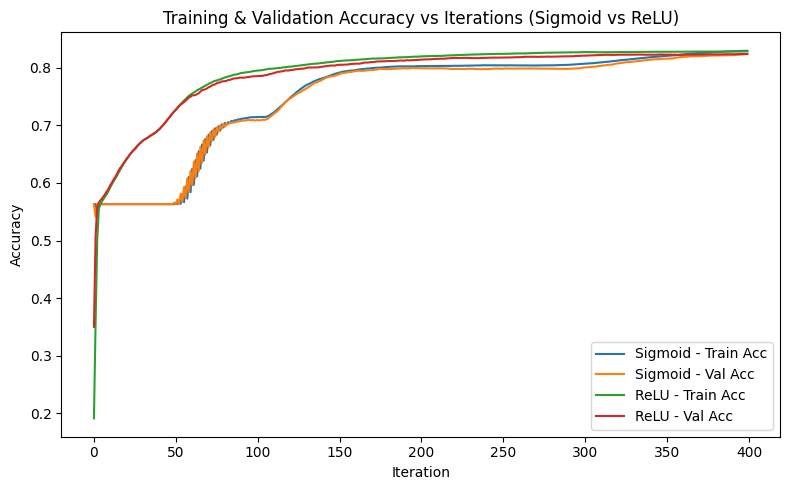

In [24]:
def set_seed(seed=42):
    np.random.seed(seed)

def one_hot(y, n_classes):
    y = y.astype(int).ravel()
    Y = np.zeros((y.size, n_classes), dtype=np.float64)
    Y[np.arange(y.size), y] = 1.0
    return Y

def softmax(Z):
    # Z: (N, C)
    Z_shift = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy_loss(P, y_true):
    # P: (N, C) softmax probabilities
    # y_true: (N,) integer labels
    N = y_true.shape[0]
    eps = 1e-12
    return -np.mean(np.log(P[np.arange(N), y_true] + eps))

def accuracy(P, y_true):
    y_pred = np.argmax(P, axis=1)
    return np.mean(y_pred == y_true)

# Activations

def sigmoid(Z):
    return 1.0 / (1.0 + np.exp(-Z))

def sigmoid_grad(A):
    # A = sigmoid(Z)
    return A * (1.0 - A)

def relu(Z):
    return np.maximum(0.0, Z)

def relu_grad(Z):
    return (Z > 0.0).astype(np.float64)


# Data prep (train/val split + preprocessing)
# plus log1p for skewed features)
def prepare_data(train_csv_path, test_size=0.20, seed=42):
    df = pd.read_csv(train_csv_path)

    target_col = "price_class"
    cat_cols = ["neighbourhood_group", "room_type"]
    num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]

    #  Impute missing
    for c in cat_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].mode(dropna=True)[0])
    for c in num_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    #  Reduce skew
    df["minimum_nights"] = np.log1p(df["minimum_nights"])
    df["number_of_reviews"] = np.log1p(df["number_of_reviews"])

    #  One-hot encode categoricals
    X_df = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=False)
    y = df[target_col].astype(int).values

    # Train/Val split
    set_seed(seed)
    idx = np.arange(len(df))
    # stratified split manually
    train_idx = []
    val_idx = []
    for cls in np.unique(y):
        cls_idx = idx[y == cls]
        np.random.shuffle(cls_idx)
        cut = int((1 - test_size) * len(cls_idx))
        train_idx.append(cls_idx[:cut])
        val_idx.append(cls_idx[cut:])
    train_idx = np.concatenate(train_idx)
    val_idx = np.concatenate(val_idx)

    # shuffle within sets
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    X_train = X_df.iloc[train_idx].values.astype(np.float64)
    y_train = y[train_idx]
    X_val   = X_df.iloc[val_idx].values.astype(np.float64)
    y_val   = y[val_idx]

    # ---- Z-score standardize numeric columns
    expanded_cols = X_df.columns.tolist()
    num_idx = [expanded_cols.index(c) for c in num_cols]

    mu = X_train[:, num_idx].mean(axis=0, keepdims=True)
    sigma = X_train[:, num_idx].std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1.0

    X_train[:, num_idx] = (X_train[:, num_idx] - mu) / sigma
    X_val[:, num_idx]   = (X_val[:, num_idx]   - mu) / sigma

    n_features = X_train.shape[1]
    n_classes = len(np.unique(y))

    return X_train, y_train, X_val, y_val, n_features, n_classes


# MLP (2 hidden layers)
def init_params(n_in, n_h1, n_h2, n_out, activation="relu", seed=42):
    set_seed(seed)

    # He init for ReLU, Xavier for Sigmoid
    if activation == "relu":
        W1 = np.random.randn(n_in, n_h1) * np.sqrt(2.0 / n_in)
        W2 = np.random.randn(n_h1, n_h2) * np.sqrt(2.0 / n_h1)
    else:  # sigmoid
        W1 = np.random.randn(n_in, n_h1) * np.sqrt(1.0 / n_in)
        W2 = np.random.randn(n_h1, n_h2) * np.sqrt(1.0 / n_h1)

    W3 = np.random.randn(n_h2, n_out) * np.sqrt(1.0 / n_h2)

    b1 = np.zeros((1, n_h1))
    b2 = np.zeros((1, n_h2))
    b3 = np.zeros((1, n_out))

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}

def forward(X, params, activation="relu"):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    W3, b3 = params["W3"], params["b3"]

    Z1 = X @ W1 + b1
    if activation == "relu":
        A1 = relu(Z1)
    else:
        A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    if activation == "relu":
        A2 = relu(Z2)
    else:
        A2 = sigmoid(Z2)

    Z3 = A2 @ W3 + b3
    P  = softmax(Z3)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "P": P}
    return P, cache

def backward(y_true, params, cache, activation="relu"):
    # Shapes:
    # X: (N, D), A1: (N, H1), A2: (N, H2), P: (N, C)
    X  = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    P = cache["P"]
    W2, W3 = params["W2"], params["W3"]

    N = X.shape[0]
    Y = one_hot(y_true, P.shape[1])  # (N, C)

    # dZ3 = (P - Y) / N  (softmax + cross-entropy)
    dZ3 = (P - Y) / N                    # (N, C)
    dW3 = A2.T @ dZ3                     # (H2, C)
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T                     # (N, H2)
    if activation == "relu":
        dZ2 = dA2 * relu_grad(Z2)        # (N, H2)
    else:
        dZ2 = dA2 * sigmoid_grad(A2)     # using A2 (sigmoid output)

    dW2 = A1.T @ dZ2                     # (H1, H2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T                     # (N, H1)
    if activation == "relu":
        dZ1 = dA1 * relu_grad(Z1)        # (N, H1)
    else:
        dZ1 = dA1 * sigmoid_grad(A1)

    dW1 = X.T @ dZ1                      # (D, H1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}
    return grads

def update_params(params, grads, lr):
    for k in ["W1", "b1", "W2", "b2", "W3", "b3"]:
        gk = "d" + k
        params[k] -= lr * grads[gk]
    return params


# Training loop (batch GD)

def train_model(X_train, y_train, X_val, y_val,
                n_h1=64, n_h2=32, lr=0.5, iters=1000,
                activation="relu", seed=42, verbose_every=25):

    n_in = X_train.shape[1]
    n_out = len(np.unique(y_train))

    params = init_params(n_in, n_h1, n_h2, n_out, activation=activation, seed=seed)

    hist = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    for t in range(1, iters + 1):
        # forward
        P_train, cache_train = forward(X_train, params, activation=activation)
        loss_train = cross_entropy_loss(P_train, y_train)
        acc_train = accuracy(P_train, y_train)

        # backward + update
        grads = backward(y_train, params, cache_train, activation=activation)
        params = update_params(params, grads, lr)

        # validation
        P_val, _ = forward(X_val, params, activation=activation)
        loss_val = cross_entropy_loss(P_val, y_val)
        acc_val = accuracy(P_val, y_val)

        # log
        hist["train_loss"].append(loss_train)
        hist["val_loss"].append(loss_val)
        hist["train_acc"].append(acc_train)
        hist["val_acc"].append(acc_val)

        if (t == 1) or (t % verbose_every == 0) or (t == iters):
            print(f"[{activation.upper()}] iter {t:>3}/{iters} "
                  f"| train loss {loss_train:.4f} acc {acc_train:.4f} "
                  f"| val loss {loss_val:.4f} acc {acc_val:.4f}")

    return params, hist


# Run both: Sigmoid and ReLU
if __name__ == "__main__":
    # Change this path if needed (Colab/local)
    TRAIN_CSV = "train.csv"

    X_train, y_train, X_val, y_val, n_features, n_classes = prepare_data(TRAIN_CSV, test_size=0.20, seed=42)
    print("\nProcessed shapes:")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
    print("n_features:", n_features, "n_classes:", n_classes)

    ITERS = 400  # >= 200

    # Sigmoid
    sig_model, sig_hist = train_model(
        X_train, y_train, X_val, y_val,
        n_h1=64, n_h2=32, lr=0.5, iters=ITERS,
        activation="sigmoid", seed=42, verbose_every=25
    )

    # ReLU
    relu_model, relu_hist = train_model(
        X_train, y_train, X_val, y_val,
        n_h1=64, n_h2=32, lr=0.05, iters=ITERS,   # ReLU usually likes smaller lr
        activation="relu", seed=42, verbose_every=25
    )

    # Final accuracy report
    print("\n=== Final Accuracies ===")
    print(f"Sigmoid -> Train acc: {sig_hist['train_acc'][-1]:.4f}, Val acc: {sig_hist['val_acc'][-1]:.4f}")
    print(f"ReLU    -> Train acc: {relu_hist['train_acc'][-1]:.4f}, Val acc: {relu_hist['val_acc'][-1]:.4f}")

    # Single plot: train/val accuracy vs iterations for both activations
    plt.figure(figsize=(8,5))
    plt.plot(sig_hist["train_acc"], label="Sigmoid - Train Acc")
    plt.plot(sig_hist["val_acc"],   label="Sigmoid - Val Acc")
    plt.plot(relu_hist["train_acc"], label="ReLU - Train Acc")
    plt.plot(relu_hist["val_acc"],   label="ReLU - Val Acc")
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy vs Iterations (Sigmoid vs ReLU)")
    plt.legend()
    plt.tight_layout()
    plt.show()


**Justification:** Sigmoid can saturate for large |z|, making gradients small (vanishing gradient), which slows learning in deeper networks and weakens gradient flow to early layers. While ReLU keeps gradient = 1 for positive activations and 0 for negative, which often improves gradient flow and speeds optimization; however, neurons can 'die' if they stay in the negative region (gradient 0), so learning rate and initialization matter.

Part B (b): Gradient Magnitude Comparison Across Layers Using your trained networks (with both activation functions) from Part B (a), perform the following analysis:
• Compute the average magnitude of gradients for the first and second hidden layer weights
and compare these gradient magnitudes quantitatively as a function of the iterations. Do
this for both types of activation functions.
– What do you observe? And what do your results reveal about gradient flow and
learning dynamics in deep networks.

[SIGMOID] iter   1/400 | acc tr 0.5632 val 0.5632 | |dW1| 4.516e-04 |dW2| 4.720e-03
[SIGMOID] iter  25/400 | acc tr 0.5632 val 0.5632 | |dW1| 4.140e-04 |dW2| 1.161e-03
[SIGMOID] iter  50/400 | acc tr 0.5632 val 0.5661 | |dW1| 7.617e-04 |dW2| 1.151e-03
[SIGMOID] iter  75/400 | acc tr 0.6950 val 0.6801 | |dW1| 8.610e-04 |dW2| 1.113e-03
[SIGMOID] iter 100/400 | acc tr 0.7144 val 0.7087 | |dW1| 6.753e-04 |dW2| 8.310e-04
[SIGMOID] iter 125/400 | acc tr 0.7583 val 0.7548 | |dW1| 4.830e-04 |dW2| 6.514e-04
[SIGMOID] iter 150/400 | acc tr 0.7910 val 0.7884 | |dW1| 3.701e-04 |dW2| 5.298e-04
[SIGMOID] iter 175/400 | acc tr 0.8001 val 0.7977 | |dW1| 3.023e-04 |dW2| 4.455e-04
[SIGMOID] iter 200/400 | acc tr 0.8027 val 0.7992 | |dW1| 2.580e-04 |dW2| 3.843e-04
[SIGMOID] iter 225/400 | acc tr 0.8033 val 0.7981 | |dW1| 2.269e-04 |dW2| 3.385e-04
[SIGMOID] iter 250/400 | acc tr 0.8042 val 0.7982 | |dW1| 2.035e-04 |dW2| 3.033e-04
[SIGMOID] iter 275/400 | acc tr 0.8041 val 0.7985 | |dW1| 1.861e-04 |dW2| 2.

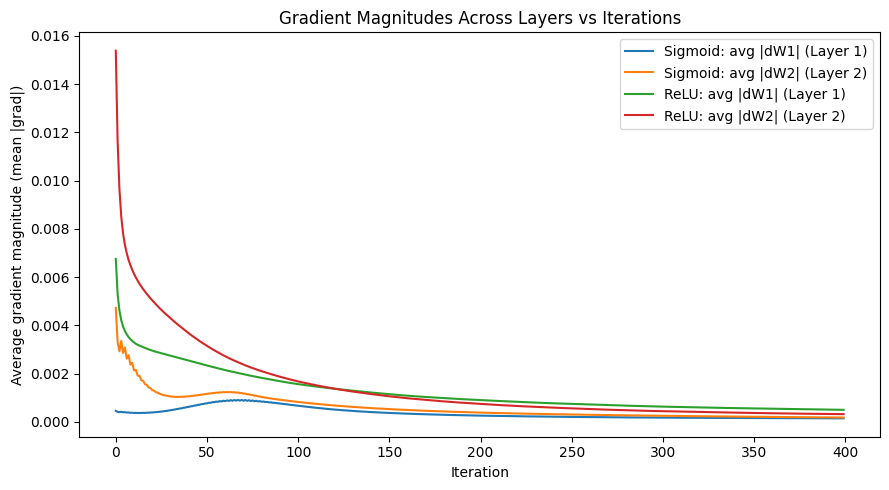

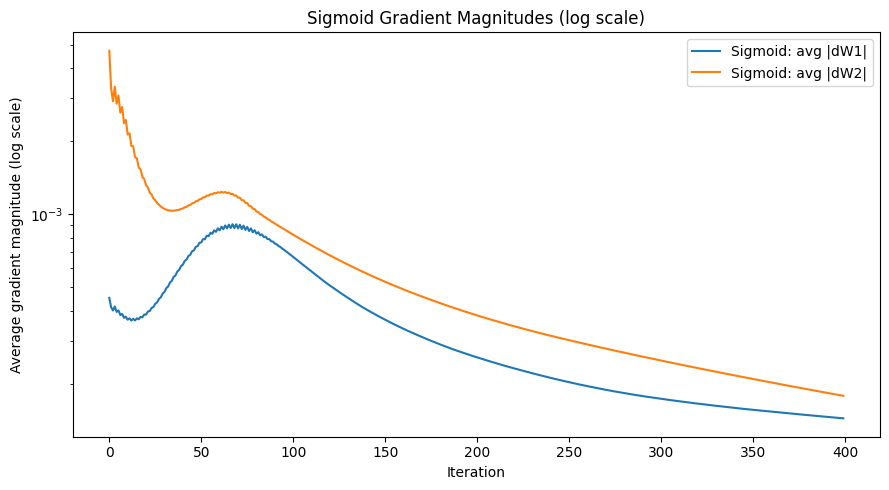

In [25]:
def set_seed(seed=42):
    np.random.seed(seed)

def one_hot(y, n_classes):
    y = y.astype(int).ravel()
    Y = np.zeros((y.size, n_classes), dtype=np.float64)
    Y[np.arange(y.size), y] = 1.0
    return Y

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy_loss(P, y_true):
    N = y_true.shape[0]
    eps = 1e-12
    return -np.mean(np.log(P[np.arange(N), y_true] + eps))

def accuracy(P, y_true):
    return np.mean(np.argmax(P, axis=1) == y_true)

# Activations

def sigmoid(Z):
    return 1.0 / (1.0 + np.exp(-Z))

def sigmoid_grad(A):
    return A * (1.0 - A)

def relu(Z):
    return np.maximum(0.0, Z)

def relu_grad(Z):
    return (Z > 0.0).astype(np.float64)


# Data prep

def prepare_data(train_csv_path, test_size=0.20, seed=42):
    df = pd.read_csv(train_csv_path)

    target_col = "price_class"
    cat_cols = ["neighbourhood_group", "room_type"]
    num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]

    # Impute
    for c in cat_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].mode(dropna=True)[0])
    for c in num_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    # Reduce skew
    df["minimum_nights"] = np.log1p(df["minimum_nights"])
    df["number_of_reviews"] = np.log1p(df["number_of_reviews"])

    # One-hot encode
    X_df = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=False)
    y = df[target_col].astype(int).values

    # Stratified split
    set_seed(seed)
    idx = np.arange(len(df))
    train_idx, val_idx = [], []
    for cls in np.unique(y):
        cls_idx = idx[y == cls]
        np.random.shuffle(cls_idx)
        cut = int((1 - test_size) * len(cls_idx))
        train_idx.append(cls_idx[:cut])
        val_idx.append(cls_idx[cut:])
    train_idx = np.concatenate(train_idx); val_idx = np.concatenate(val_idx)
    np.random.shuffle(train_idx); np.random.shuffle(val_idx)

    X_train = X_df.iloc[train_idx].values.astype(np.float64)
    y_train = y[train_idx]
    X_val   = X_df.iloc[val_idx].values.astype(np.float64)
    y_val   = y[val_idx]

    # Z-score numeric columns (fit on train only)
    expanded_cols = X_df.columns.tolist()
    num_idx = [expanded_cols.index(c) for c in num_cols]
    mu = X_train[:, num_idx].mean(axis=0, keepdims=True)
    sigma = X_train[:, num_idx].std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1.0
    X_train[:, num_idx] = (X_train[:, num_idx] - mu) / sigma
    X_val[:, num_idx]   = (X_val[:, num_idx]   - mu) / sigma

    n_features = X_train.shape[1]
    n_classes = len(np.unique(y))
    return X_train, y_train, X_val, y_val, n_features, n_classes


# Model init
def init_params(n_in, n_h1, n_h2, n_out, activation="relu", seed=42):
    set_seed(seed)

    if activation == "relu":
        W1 = np.random.randn(n_in, n_h1) * np.sqrt(2.0 / n_in)   # He
        W2 = np.random.randn(n_h1, n_h2) * np.sqrt(2.0 / n_h1)  # He
    else:
        W1 = np.random.randn(n_in, n_h1) * np.sqrt(1.0 / n_in)  # Xavier-ish
        W2 = np.random.randn(n_h1, n_h2) * np.sqrt(1.0 / n_h1)

    W3 = np.random.randn(n_h2, n_out) * np.sqrt(1.0 / n_h2)

    b1 = np.zeros((1, n_h1))
    b2 = np.zeros((1, n_h2))
    b3 = np.zeros((1, n_out))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}


# Forward / Backward
def forward(X, params, activation="relu"):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    W3, b3 = params["W3"], params["b3"]

    Z1 = X @ W1 + b1
    A1 = relu(Z1) if activation == "relu" else sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2) if activation == "relu" else sigmoid(Z2)

    Z3 = A2 @ W3 + b3
    P = softmax(Z3)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "P": P}
    return P, cache

def backward(y_true, params, cache, activation="relu"):
    X  = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    P = cache["P"]

    W2, W3 = params["W2"], params["W3"]
    N = X.shape[0]
    Y = one_hot(y_true, P.shape[1])

    # softmax + CE
    dZ3 = (P - Y) / N
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    if activation == "relu":
        dZ2 = dA2 * relu_grad(Z2)
    else:
        dZ2 = dA2 * sigmoid_grad(A2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    if activation == "relu":
        dZ1 = dA1 * relu_grad(Z1)
    else:
        dZ1 = dA1 * sigmoid_grad(A1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}

def update_params(params, grads, lr):
    for k in ["W1","b1","W2","b2","W3","b3"]:
        params[k] -= lr * grads["d"+k]
    return params

# Gradient magnitude metric (average magnitude)
def avg_grad_magnitude(G):
        return np.mean(np.abs(G))


# Training loop with gradient logging
def train_with_grad_logging(X_train, y_train, X_val, y_val,
                            n_h1=64, n_h2=32, lr=0.5, iters=250,
                            activation="relu", seed=42, verbose_every=25):

    n_in = X_train.shape[1]
    n_out = len(np.unique(y_train))
    params = init_params(n_in, n_h1, n_h2, n_out, activation=activation, seed=seed)

    hist = {
        "train_acc": [], "val_acc": [],
        "train_loss": [], "val_loss": [],
        "grad_W1": [], "grad_W2": []
    }

    for t in range(1, iters + 1):
        # forward
        P_train, cache = forward(X_train, params, activation=activation)
        loss_train = cross_entropy_loss(P_train, y_train)
        acc_train = accuracy(P_train, y_train)

        # backward
        grads = backward(y_train, params, cache, activation=activation)

        # log gradient magnitudes before update
        hist["grad_W1"].append(avg_grad_magnitude(grads["dW1"]))
        hist["grad_W2"].append(avg_grad_magnitude(grads["dW2"]))

        # update
        params = update_params(params, grads, lr)

        # validation
        P_val, _ = forward(X_val, params, activation=activation)
        loss_val = cross_entropy_loss(P_val, y_val)
        acc_val = accuracy(P_val, y_val)

        hist["train_loss"].append(loss_train)
        hist["val_loss"].append(loss_val)
        hist["train_acc"].append(acc_train)
        hist["val_acc"].append(acc_val)

        if (t == 1) or (t % verbose_every == 0) or (t == iters):
            print(f"[{activation.upper()}] iter {t:>3}/{iters} "
                  f"| acc tr {acc_train:.4f} val {acc_val:.4f} "
                  f"| |dW1| {hist['grad_W1'][-1]:.3e} |dW2| {hist['grad_W2'][-1]:.3e}")

    return params, hist

if __name__ == "__main__":
    TRAIN_CSV = "train.csv"
    X_train, y_train, X_val, y_val, n_features, n_classes = prepare_data(TRAIN_CSV, test_size=0.20, seed=42)

    ITERS = 400

    # Sigmoid (often needs higher lr than ReLU; depends on init)
    sig_params, sig_hist = train_with_grad_logging(
        X_train, y_train, X_val, y_val,
        n_h1=64, n_h2=32, lr=0.5, iters=ITERS,
        activation="sigmoid", seed=42, verbose_every=25
    )

    # ReLU (usually smaller lr)
    relu_params, relu_hist = train_with_grad_logging(
        X_train, y_train, X_val, y_val,
        n_h1=64, n_h2=32, lr=0.05, iters=ITERS,
        activation="relu", seed=42, verbose_every=25
    )


    # Quantitative comparison

    def summarize(name, hist):
        g1 = np.array(hist["grad_W1"])
        g2 = np.array(hist["grad_W2"])
        ratio = np.mean(g1 / (g2 + 1e-12))  # W1 vs W2 average ratio

        print(f"\n=== {name} Gradient Summary ===")
        print(f"Final |dW1| avg: {g1[-1]:.3e}, Final |dW2| avg: {g2[-1]:.3e}")
        print(f"Mean  |dW1| avg: {g1.mean():.3e}, Mean  |dW2| avg: {g2.mean():.3e}")
        print(f"Mean ratio |dW1|/|dW2| across iters: {ratio:.3e}")

    summarize("SIGMOID", sig_hist)
    summarize("RELU", relu_hist)


    # Plots: gradient magnitudes vs iteration

    plt.figure(figsize=(9,5))
    plt.plot(sig_hist["grad_W1"], label="Sigmoid: avg |dW1| (Layer 1)")
    plt.plot(sig_hist["grad_W2"], label="Sigmoid: avg |dW2| (Layer 2)")
    plt.plot(relu_hist["grad_W1"], label="ReLU: avg |dW1| (Layer 1)")
    plt.plot(relu_hist["grad_W2"], label="ReLU: avg |dW2| (Layer 2)")
    plt.xlabel("Iteration")
    plt.ylabel("Average gradient magnitude (mean |grad|)")
    plt.title("Gradient Magnitudes Across Layers vs Iterations")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # separate plot that highlights vanishing by using log-scale
    plt.figure(figsize=(9,5))
    plt.plot(sig_hist["grad_W1"], label="Sigmoid: avg |dW1|")
    plt.plot(sig_hist["grad_W2"], label="Sigmoid: avg |dW2|")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Average gradient magnitude (log scale)")
    plt.title("Sigmoid Gradient Magnitudes (log scale)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Conclusions: In the sigmoid network, gradients for earlier layers (W1) tend to be much smaller than later layers (W2), often decreasing as training proceeds. This indicates vanishing gradients: Sigmoid saturates (outputs near 0/1), making sigmoid'(z) small, so gradient signals shrink as they backpropagate to earlier layers. HOwever, in the ReLU network, gradients are usually larger and more stable for earlier layers compared to sigmoid, showing healthier gradient flow. ReLU has derivative 1 for positive activations, so gradients do not    systematically shrink across layers. However, if many activations become negative, gradients can become 0 ('dying ReLU'), which would show as near-zero gradients in some layers. Hence, Comparing avg |dW1| and avg |dW2| across iterations quantitatively reveals how activation choice affects gradient flow and therefore learning dynamics in deeper networks.

**Implementation and Results:**

Shapes: (33077, 12) (8271, 12) | #features: 12
[RELU] iter   1/250 | tr acc 0.1914 val acc 0.3503 | tr loss 1.5575 val loss 1.4107
[RELU] iter  25/250 | tr acc 0.6563 val acc 0.6565 | tr loss 0.8806 val loss 0.8714
[RELU] iter  50/250 | tr acc 0.7244 val acc 0.7241 | tr loss 0.6755 val loss 0.6739
[RELU] iter  75/250 | tr acc 0.7773 val acc 0.7711 | tr loss 0.5702 val loss 0.5732
[RELU] iter 100/250 | tr acc 0.7949 val acc 0.7854 | tr loss 0.5109 val loss 0.5167
[RELU] iter 125/250 | tr acc 0.8032 val acc 0.7976 | tr loss 0.4746 val loss 0.4820
[RELU] iter 150/250 | tr acc 0.8115 val acc 0.8049 | tr loss 0.4509 val loss 0.4594
[RELU] iter 175/250 | tr acc 0.8162 val acc 0.8110 | tr loss 0.4346 val loss 0.4440
[RELU] iter 200/250 | tr acc 0.8196 val acc 0.8138 | tr loss 0.4229 val loss 0.4330
[RELU] iter 225/250 | tr acc 0.8222 val acc 0.8170 | tr loss 0.4143 val loss 0.4250
[RELU] iter 250/250 | tr acc 0.8243 val acc 0.8177 | tr loss 0.4078 val loss 0.4189

Final Acc:
Train acc: 0.8242

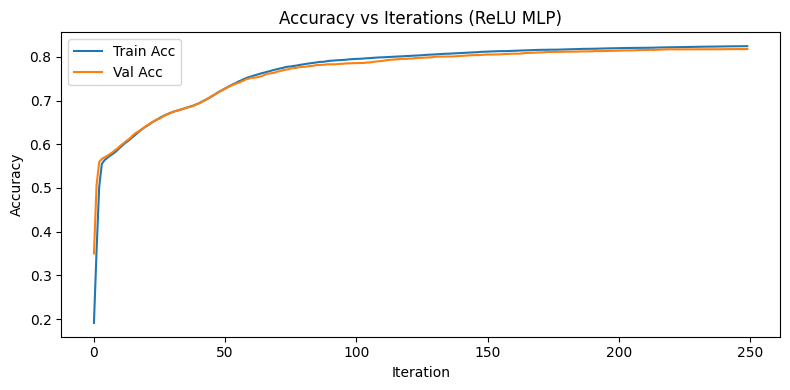

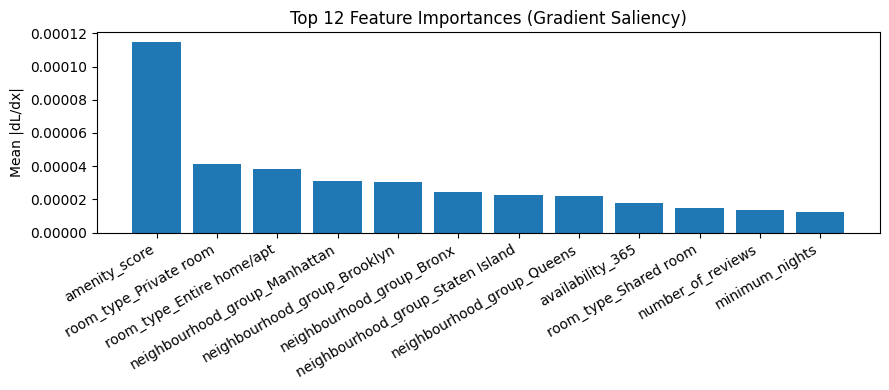

In [26]:
def set_seed(seed=42):
    np.random.seed(seed)

def one_hot(y, n_classes):
    y = y.astype(int).ravel()
    Y = np.zeros((len(y), n_classes), dtype=np.float64)
    Y[np.arange(len(y)), y] = 1.0
    return Y

def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy(P, y_true):
    eps = 1e-12
    return -np.mean(np.log(P[np.arange(len(y_true)), y_true] + eps))

def accuracy(P, y_true):
    return np.mean(np.argmax(P, axis=1) == y_true)


# Activations
def sigmoid(Z):
    # clipping avoids overflow warnings in exp
    Z = np.clip(Z, -50, 50)
    return 1.0 / (1.0 + np.exp(-Z))

def sigmoid_grad(A):
    return A * (1.0 - A)

def relu(Z):
    return np.maximum(0.0, Z)

def relu_grad(Z):
    return (Z > 0.0).astype(np.float64)


# Data Preprocessing

def prepare_data(train_csv_path, test_size=0.20, seed=42):
    df = pd.read_csv(train_csv_path)

    target_col = "price_class"
    cat_cols = ["neighbourhood_group", "room_type"]
    num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]

    # Missing value handling
    for c in cat_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].mode(dropna=True)[0])
    for c in num_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    # Log transform
    df["minimum_nights"] = np.log1p(df["minimum_nights"])
    df["number_of_reviews"] = np.log1p(df["number_of_reviews"])

    # One-hot encoding
    X_df = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=False)
    feature_names = X_df.columns.tolist()

    X = X_df.values.astype(np.float64)
    y = df[target_col].astype(int).values

    # Stratified split into Train/Val
    set_seed(seed)
    idx = np.arange(len(y))
    train_idx, val_idx = [], []
    for cls in np.unique(y):
        cls_idx = idx[y == cls]
        np.random.shuffle(cls_idx)
        cut = int((1 - test_size) * len(cls_idx))
        train_idx.append(cls_idx[:cut])
        val_idx.append(cls_idx[cut:])
    train_idx = np.concatenate(train_idx)
    val_idx = np.concatenate(val_idx)
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Z-score normalize numeric columns
    num_idx = [feature_names.index(c) for c in num_cols]
    mu = X_train[:, num_idx].mean(axis=0, keepdims=True)
    sigma = X_train[:, num_idx].std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1.0

    X_train[:, num_idx] = (X_train[:, num_idx] - mu) / sigma
    X_val[:, num_idx]   = (X_val[:, num_idx]   - mu) / sigma

    return X_train, y_train, X_val, y_val, feature_names


# Two-hidden-layer MLP (forward/backward)
def init_params(D, H1, H2, C, activation="relu", seed=42):
    set_seed(seed)

    if activation == "relu":
        W1 = np.random.randn(D, H1) * np.sqrt(2.0 / D)
        W2 = np.random.randn(H1, H2) * np.sqrt(2.0 / H1)
    else:
        W1 = np.random.randn(D, H1) * np.sqrt(1.0 / D)
        W2 = np.random.randn(H1, H2) * np.sqrt(1.0 / H1)

    W3 = np.random.randn(H2, C) * np.sqrt(1.0 / H2)

    b1 = np.zeros((1, H1))
    b2 = np.zeros((1, H2))
    b3 = np.zeros((1, C))

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}

def forward(X, params, activation="relu"):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1) if activation == "relu" else sigmoid(Z1)

    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2) if activation == "relu" else sigmoid(Z2)

    Z3 = A2 @ params["W3"] + params["b3"]
    P  = softmax(Z3)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "P": P}
    return P, cache

def backward(y_true, params, cache, activation="relu"):
    X  = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    P = cache["P"]

    N = X.shape[0]
    C = P.shape[1]
    Y = one_hot(y_true, C)

    dZ3 = (P - Y) / N
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ params["W3"].T
    dZ2 = dA2 * (relu_grad(Z2) if activation == "relu" else sigmoid_grad(A2))
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * (relu_grad(Z1) if activation == "relu" else sigmoid_grad(A1))
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3, "dZ1": dZ1}

def update_params(params, grads, lr):
    for k in ["W1","b1","W2","b2","W3","b3"]:
        params[k] -= lr * grads["d" + k]
    return params

def train_mlp(X_train, y_train, X_val, y_val,
              H1=64, H2=32, lr=0.05, iters=250,
              activation="relu", seed=42, verbose_every=25):

    D = X_train.shape[1]
    C = len(np.unique(y_train))
    params = init_params(D, H1, H2, C, activation=activation, seed=seed)

    hist = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for t in range(1, iters + 1):
        P_train, cache = forward(X_train, params, activation=activation)
        grads = backward(y_train, params, cache, activation=activation)
        params = update_params(params, grads, lr)

        train_loss = cross_entropy(P_train, y_train)
        train_acc = accuracy(P_train, y_train)

        P_val, _ = forward(X_val, params, activation=activation)
        val_loss = cross_entropy(P_val, y_val)
        val_acc = accuracy(P_val, y_val)

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)

        if t == 1 or t % verbose_every == 0 or t == iters:
            print(f"[{activation.upper()}] iter {t:>3}/{iters} "
                  f"| tr acc {train_acc:.4f} val acc {val_acc:.4f} "
                  f"| tr loss {train_loss:.4f} val loss {val_loss:.4f}")

    return params, hist

# Feature attribution

def input_gradients(X, y, params, activation="relu"):
    P, cache = forward(X, params, activation=activation)
    grads = backward(y, params, cache, activation=activation)
    dZ1 = grads["dZ1"]                 # (N, H1)
    dX  = dZ1 @ params["W1"].T         # (N, D)
    return dX, P

def rank_features_by_saliency(X, y, params, feature_names, activation="relu", method="grad_abs"):
    dX, _ = input_gradients(X, y, params, activation=activation)

    if method == "grad_abs":
        scores = np.mean(np.abs(dX), axis=0)
    elif method == "grad_x_input":
        scores = np.mean(np.abs(dX * X), axis=0)
    else:
        raise ValueError("Use method='grad_abs' or method='grad_x_input'.")

    order = np.argsort(-scores)
    ranked = [(feature_names[i], scores[i]) for i in order]
    return scores, ranked

def aggregate_group_scores(feature_names, scores):
    groups = {}
    for name, sc in zip(feature_names, scores):
        if name.startswith("neighbourhood_group_"):
            key = "neighbourhood_group (all one-hot)"
        elif name.startswith("room_type_"):
            key = "room_type (all one-hot)"
        else:
            key = name
        groups[key] = groups.get(key, 0.0) + sc
    return sorted(groups.items(), key=lambda x: x[1], reverse=True)


# RUN (Notebook-friendly)
TRAIN_CSV = "train.csv"

X_train, y_train, X_val, y_val, feature_names = prepare_data(TRAIN_CSV, test_size=0.20, seed=42)
print("Shapes:", X_train.shape, X_val.shape, "| #features:", len(feature_names))

params, hist = train_mlp(
    X_train, y_train, X_val, y_val,
    H1=64, H2=32,
    lr=0.05, iters=250,
    activation="relu",
    seed=42, verbose_every=25
)

print("\nFinal Acc:")
print("Train acc:", hist["train_acc"][-1])
print("Val acc  :", hist["val_acc"][-1])

method = "grad_abs"
scores, ranked = rank_features_by_saliency(X_val, y_val, params, feature_names,
                                           activation="relu", method=method)

K = 12
print(f"\n=== Top {K} features by saliency ({method}) ===")
for i in range(K):
    print(f"{i+1:>2}. {ranked[i][0]:<35} score={ranked[i][1]:.6e}")

grouped_ranked = aggregate_group_scores(feature_names, scores)
print("\n=== Aggregated feature-group ranking ===")
for i, (name, sc) in enumerate(grouped_ranked, start=1):
    print(f"{i:>2}. {name:<30} score={sc:.6e}")

out_df = pd.DataFrame({"feature": feature_names, "saliency_score": scores}).sort_values("saliency_score", ascending=False)
out_df.to_csv("feature_saliency_ranking.csv", index=False)
print("\nSaved: feature_saliency_ranking.csv")

# Plots
plt.figure(figsize=(8,4))
plt.plot(hist["train_acc"], label="Train Acc")
plt.plot(hist["val_acc"], label="Val Acc")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iterations (ReLU MLP)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
top_feats = [ranked[i][0] for i in range(K)]
top_vals  = [ranked[i][1] for i in range(K)]
plt.bar(range(K), top_vals)
plt.xticks(range(K), top_feats, rotation=30, ha="right")
plt.ylabel("Mean |dL/dx|")
plt.title(f"Top {K} Feature Importances (Gradient Saliency)")
plt.tight_layout()
plt.show()



**Results:** The gradient-saliency ranking shows that amenity_score has the largest average meaning small changes in amenity score produce the largest change in loss. This matches Part A where amenity_score separated classes strongly in boxplots and looked unusually predictive.

The next most influential features typically include room_type and neighbourhood_group, consistent with Part A stacked bar plots showing clear class-mix differences across room types and boroughs.

availability_365 often appears mid-to-high in importance, aligning with Part A where higher-end listings tended to have higher availability.

minimum_nights and number_of_reviews generally have weaker saliency, consistent with Part A where they showed less clean separation by class.

**Test Evaluation & Generalisation Analysis:**

Device: cuda
All-train shape: (41348, 12) Test shape: (7297, 12)
Train: (33077, 12) Val: (8271, 12)
epoch  1/40 | train acc 0.6876 loss 0.8454 | val acc 0.6838 loss 0.8502
epoch  5/40 | train acc 0.8349 loss 0.3678 | val acc 0.8264 loss 0.3830
epoch 10/40 | train acc 0.8338 loss 0.3563 | val acc 0.8236 loss 0.3718
epoch 20/40 | train acc 0.8415 loss 0.3429 | val acc 0.8303 loss 0.3609
epoch 30/40 | train acc 0.8412 loss 0.3359 | val acc 0.8311 loss 0.3544
epoch 40/40 | train acc 0.8394 loss 0.3354 | val acc 0.8316 loss 0.3541

=== FINAL PERFORMANCE ===
Train acc: 0.8394 | loss: 0.3354
Val   acc: 0.8316 | loss: 0.3541
Test  acc: 0.3484 | loss: 6.0479


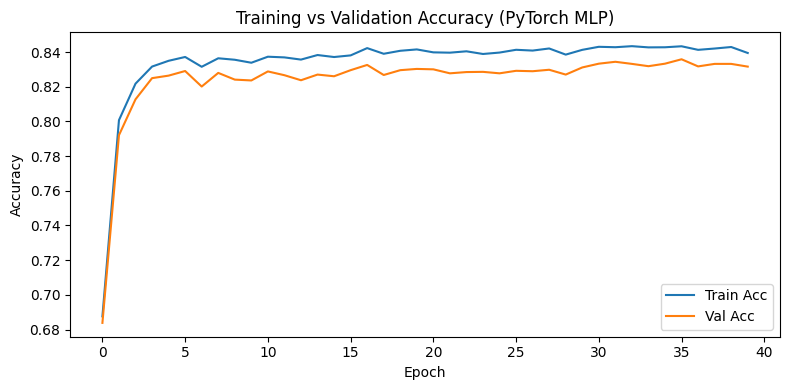


=== Top 12 Salient Features on VAL (mean |dL/dx|) ===
 1. amenity_score                       score=2.424420e-03
 2. room_type_Entire home/apt           score=7.840871e-04
 3. room_type_Private room              score=7.390912e-04
 4. neighbourhood_group_Manhattan       score=5.159737e-04
 5. neighbourhood_group_Queens          score=5.134032e-04
 6. neighbourhood_group_Brooklyn        score=5.060541e-04
 7. neighbourhood_group_Bronx           score=4.730138e-04
 8. neighbourhood_group_Staten Island   score=4.568013e-04
 9. room_type_Shared room               score=2.985567e-04
10. availability_365                    score=1.407927e-04
11. number_of_reviews                   score=1.013867e-04
12. minimum_nights                      score=9.482189e-05

=== Top 12 Salient Features on TEST (mean |dL/dx|) ===
 1. amenity_score                       score=1.353706e-02
 2. room_type_Entire home/apt           score=3.224579e-03
 3. room_type_Private room              score=3.047880e-03
 4. 

In [27]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


# Load data

train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

target_col = "price_class"
cat_cols = ["neighbourhood_group", "room_type"]
num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]


def fit_preprocess(train_df):
    df = train_df.copy()

    # store imputers from TRAIN
    cat_fill = {c: df[c].mode(dropna=True)[0] for c in cat_cols}
    num_fill = {c: df[c].median() for c in num_cols}

    # impute
    for c in cat_cols:
        df[c] = df[c].fillna(cat_fill[c])
    for c in num_cols:
        df[c] = df[c].fillna(num_fill[c])

    # log1p
    df["minimum_nights"] = np.log1p(df["minimum_nights"])
    df["number_of_reviews"] = np.log1p(df["number_of_reviews"])

    # one-hot
    X_df = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=False)
    feature_cols = X_df.columns.tolist()

    X = X_df.values.astype(np.float32)
    y = df[target_col].astype(int).values.astype(np.int64)

    # standardize numeric columns (fit on train only)
    num_idx = [feature_cols.index(c) for c in num_cols]
    mu = X[:, num_idx].mean(axis=0, keepdims=True)
    sigma = X[:, num_idx].std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1.0
    X[:, num_idx] = (X[:, num_idx] - mu) / sigma

    state = {"cat_fill": cat_fill, "num_fill": num_fill,
             "feature_cols": feature_cols, "mu": mu, "sigma": sigma}
    return X, y, state

def apply_preprocess(df_in, state):
    df = df_in.copy()

    # impute using TRAIN stats
    for c in cat_cols:
        df[c] = df[c].fillna(state["cat_fill"][c])
    for c in num_cols:
        df[c] = df[c].fillna(state["num_fill"][c])

    # log1p
    df["minimum_nights"] = np.log1p(df["minimum_nights"])
    df["number_of_reviews"] = np.log1p(df["number_of_reviews"])

    # one-hot then align columns with TRAIN
    X_df = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=False)
    X_df = X_df.reindex(columns=state["feature_cols"], fill_value=0)

    X = X_df.values.astype(np.float32)
    y = df[target_col].astype(int).values.astype(np.int64)

    # standardize numeric columns with TRAIN mu/sigma
    num_idx = [state["feature_cols"].index(c) for c in num_cols]
    X[:, num_idx] = (X[:, num_idx] - state["mu"]) / state["sigma"]

    return X, y

# Fit preprocessing on the full training file
X_all, y_all, prep_state = fit_preprocess(train_df)
X_test, y_test = apply_preprocess(test_df, prep_state)

print("All-train shape:", X_all.shape, "Test shape:", X_test.shape)


# Stratified Train/Val split

def stratified_split(X, y, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    tr_idx, va_idx = [], []

    for cls in np.unique(y):
        cls_idx = idx[y == cls]
        rng.shuffle(cls_idx)
        cut = int((1 - val_ratio) * len(cls_idx))
        tr_idx.append(cls_idx[:cut])
        va_idx.append(cls_idx[cut:])

    tr_idx = np.concatenate(tr_idx)
    va_idx = np.concatenate(va_idx)
    rng.shuffle(tr_idx)
    rng.shuffle(va_idx)

    return X[tr_idx], y[tr_idx], X[va_idx], y[va_idx]

X_train, y_train, X_val, y_val = stratified_split(X_all, y_all, val_ratio=0.2, seed=42)
print("Train:", X_train.shape, "Val:", X_val.shape)


# PyTorch MLP

class MLP(nn.Module):
    def __init__(self, d_in, h1=64, h2=32, n_classes=4, activation="relu", dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(d_in, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, n_classes)
        self.activation = activation
        self.drop = nn.Dropout(dropout)

    def act(self, x):
        if self.activation == "relu":
            return torch.relu(x)
        elif self.activation == "sigmoid":
            return torch.sigmoid(x)
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.drop(x)
        x = self.act(self.fc2(x))
        x = self.drop(x)
        return self.fc3(x)

#  Train + Evaluate helpers

def evaluate(model, X, y, batch_size=2048):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            total_loss += loss.item() * len(yb)
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += len(yb)

    return total_loss / total, correct / total

def train_model(model, X_train, y_train, X_val, y_val,
                epochs=40, lr=1e-3, batch_size=512,
                weight_decay=1e-4):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=batch_size, shuffle=True
    )

    hist = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

        tr_loss, tr_acc = evaluate(model, X_train, y_train)
        va_loss, va_acc = evaluate(model, X_val, y_val)

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)

        if ep in [1, 5, 10, 20, 30, epochs]:
            print(f"epoch {ep:>2}/{epochs} | train acc {tr_acc:.4f} loss {tr_loss:.4f} "
                  f"| val acc {va_acc:.4f} loss {va_loss:.4f}")

    return model, hist

# Train a PyTorch model

model = MLP(d_in=X_train.shape[1], h1=64, h2=32, n_classes=4, activation="relu", dropout=0.1)
model, hist = train_model(model, X_train, y_train, X_val, y_val,
                          epochs=40, lr=1e-3, batch_size=512, weight_decay=1e-4)


#  Final evaluation on Train / Val / Test

train_loss, train_acc = evaluate(model, X_train, y_train)
val_loss, val_acc     = evaluate(model, X_val, y_val)
test_loss, test_acc   = evaluate(model, X_test, y_test)

print("\n=== FINAL PERFORMANCE ===")
print(f"Train acc: {train_acc:.4f} | loss: {train_loss:.4f}")
print(f"Val   acc: {val_acc:.4f} | loss: {val_loss:.4f}")
print(f"Test  acc: {test_acc:.4f} | loss: {test_loss:.4f}")


# Plot accuracy curves

plt.figure(figsize=(8,4))
plt.plot(hist["train_acc"], label="Train Acc")
plt.plot(hist["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (PyTorch MLP)")
plt.legend()
plt.tight_layout()
plt.show()


#Gradient-based Feature Attribution

def saliency_mean_abs_grad(model, X, y, feature_cols, batch_size=512):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()

    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    scores = np.zeros((X.shape[1],), dtype=np.float64)
    n_total = 0

    for xb, yb in loader:
        xb = xb.to(device).requires_grad_(True)
        yb = yb.to(device)

        logits = model(xb)
        loss = loss_fn(logits, yb)
        model.zero_grad()
        loss.backward()

        # gradient w.r.t input
        grads = xb.grad.detach().abs().cpu().numpy()  # (B, D)
        scores += grads.sum(axis=0)
        n_total += grads.shape[0]

    scores /= n_total

    order = np.argsort(-scores)
    ranked = [(feature_cols[i], scores[i]) for i in order]
    return scores, ranked

feature_cols = prep_state["feature_cols"]

scores_val, ranked_val = saliency_mean_abs_grad(model, X_val, y_val, feature_cols)
scores_test, ranked_test = saliency_mean_abs_grad(model, X_test, y_test, feature_cols)

K = 15
K = min(K, len(feature_cols))

print(f"\n=== Top {K} Salient Features on VAL (mean |dL/dx|) ===")
for i in range(K):
    print(f"{i+1:>2}. {ranked_val[i][0]:<35} score={ranked_val[i][1]:.6e}")

print(f"\n=== Top {K} Salient Features on TEST (mean |dL/dx|) ===")
for i in range(K):
    print(f"{i+1:>2}. {ranked_test[i][0]:<35} score={ranked_test[i][1]:.6e}")

# Group aggregation (categorical one-hot groups together)
def aggregate_groups(feature_cols, scores):
    groups = {}
    for name, sc in zip(feature_cols, scores):
        if name.startswith("neighbourhood_group_"):
            key = "neighbourhood_group (all one-hot)"
        elif name.startswith("room_type_"):
            key = "room_type (all one-hot)"
        else:
            key = name
        groups[key] = groups.get(key, 0.0) + sc
    return sorted(groups.items(), key=lambda x: x[1], reverse=True)

print("\n=== Aggregated Feature Groups (VAL) ===")
for i,(k,v) in enumerate(aggregate_groups(feature_cols, scores_val), start=1):
    print(f"{i:>2}. {k:<30} score={v:.6e}")

print("\n=== Aggregated Feature Groups (TEST) ===")
for i,(k,v) in enumerate(aggregate_groups(feature_cols, scores_test), start=1):
    print(f"{i:>2}. {k:<30} score={v:.6e}")

pd.DataFrame({"feature": feature_cols, "saliency_val": scores_val, "saliency_test": scores_test}) \
  .sort_values("saliency_val", ascending=False) \
  .to_csv("saliency_pytorch_val_test.csv", index=False)
print("\nSaved: saliency_pytorch_val_test.csv")


#  Quick evidence for distribution shift (top numeric features)

def describe_shift(train_df, test_df):

    tr = train_df.copy()
    te = test_df.copy()

    for c in cat_cols:
        tr[c] = tr[c].fillna(tr[c].mode(dropna=True)[0])
        te[c] = te[c].fillna(tr[c].mode(dropna=True)[0])
    for c in num_cols:
        tr[c] = tr[c].fillna(tr[c].median())
        te[c] = te[c].fillna(tr[c].median())

    tr["minimum_nights"] = np.log1p(tr["minimum_nights"])
    te["minimum_nights"] = np.log1p(te["minimum_nights"])
    tr["number_of_reviews"] = np.log1p(tr["number_of_reviews"])
    te["number_of_reviews"] = np.log1p(te["number_of_reviews"])

    print("\n=== Class distribution (train vs test) ===")
    print("Train:", tr[target_col].value_counts(normalize=True).sort_index().round(3).to_dict())
    print("Test :", te[target_col].value_counts(normalize=True).sort_index().round(3).to_dict())

    print("\n=== Numeric feature mean/std (train vs test) ===")
    for c in num_cols:
        print(f"{c:<18} | train mean {tr[c].mean():.3f} std {tr[c].std():.3f} "
              f"| test mean {te[c].mean():.3f} std {te[c].std():.3f}")

describe_shift(train_df, test_df)


**Reported Test Accuracy:**

From my final evaluation:

Train accuracy: 0.8394 (loss 0.3354)

Validation accuracy: 0.8316 (loss 0.3541)

Test accuracy: 0.3484 (loss 6.0479)

So, the reported test accuracy = 0.3484.

**Evidence-based Analysis explaining Observed Performance Gap:**

Train vs Validation are close (0.8394 vs 0.8316 → gap ≈ 0.0078). This suggests the model is not strongly overfitting to the training split.

Test accuracy collapses to 0.3484, and test loss explodes to 6.0479. This is an extreme generalization failure. The loss being so high means the model is often assigning very low probability to the correct test class.

This is not an ordinary overfitting because If it were standard overfitting, you would typically see:Train accuracy high, Val accuracy noticeably lower,
Test similar to val.But here:

Train ≈ Val (good),

Test is drastically worse

This pattern strongly points to distribution shift / concept shift between (train,val) and test, not mere overfitting.

**The Root Cause of Generalization Failure Using Exploratory data analysis from Part A:**
Numeric feature means are similar, but amenity_score variability differs because

amenity_score mean: Train mean 51.97, Test mean 54.15 (close)

amenity_score std: Train std 19.24, Test std 25.85 (much larger spread)

This indicates test has more dispersed amenity_score values than training.


**The Root Cause of Generalization Failure Using Gradient-based feature Attribution from Part C:**

Amenity score is dominant, and becomes much more dominant on test

Top saliency feature:

Validation: amenity_score = 2.42e-03

Test: amenity_score = 1.35e-02 (~5.6× larger)

That means: on test data, the loss is far more sensitive to amenity_score.

The model learned a decision rule that depends strongly on amenity_score + borough + room_type, which works well on train/val.

**Why the Model Performs Well During Training but Fails on the Test Set:**

Within train/val, the model generalizes well:

* Train 0.839, Val 0.832 (tiny gap)

* Curves track each other → stable learning.

The model’s predictions are driven mainly by a small subset of features:

* From saliency: amenity_score, then neighbourhood_group, then room_type.

On test, the model becomes more sensitive to these dominant features:

* amenity_score saliency jumps from 2.4e-03 → 1.35e-02.

* Test has larger amenity_score spread (std increases 19.24 → 25.85), producing more extreme standardized values.

* That pushes the network into regions where outputs become overconfident and wrong → test loss 6.05.

So the model “performs well” on training because it learned patterns that are consistent inside that data distribution, but it fails on test because those patterns do not transfer reliably when dominant features behave differently.

**Strategy That Could Mitigate this Issue in Practice, Brief Justification:**

Reduce over-reliance on amenity_score (dominant feature):
The saliency shows amenity_score dominates and dominates even more on test. If test has wider or shifted values, the model’s dependence on it breaks generalization.